# Hamiltonian Simulation with Qubitization (Chebyshev LCU)

> **Simulating physical and chemical systems** was among the original motivations for quantum computing, as first envisioned by Richard Feynman in 1982, and remains one of its most impactful applications. Time-independent Hamiltonian simulation refers to the task of approximately implementing the unitary evolution operator $e^{-iHt}$ for a Hermitian matrix $H$. When access to the Hamiltonian is provided via block-encoding, this can be realized by applying an appropriate polynomial transformation within a desired precision $\epsilon$.
>
> **Qubitization** [<a href="#ref-bck">1</a>] achieves Hamiltonian simulation by combining the Jacobi–Anger expansion with the Linear Combination of Unitaries (LCU) technique, exploiting the fact that powers of the walk operator directly implement Chebyshev polynomial block-encodings. This approach is entirely constructive- it requires **no classical preprocessing** for rotation angles, but uses more ancilla qubits ($O(\log d)$, where $d$ is the polynomial degree) than GQSP or QSVT.
>
> - **Input:** A Hermitian operator $H$ given through a block-encoding unitary $U_H$ with scaling factor $\alpha \ge \|H\|$, evolution time $t$, and target error $\epsilon$.
> - **Output:** A unitary $U$ approximating $e^{-iHt}$, with $\|U - e^{-iHt}\| < \epsilon$.
>
> **Complexity:** $O\!\left(\alpha t + \frac{\log \epsilon^{-1}}{\log\!\left(e + \log(\epsilon^{-1}) / \alpha t\right)}\right)$ calls to the block-encoding, using $O(\log d)$ auxiliary qubits. No classical angle preprocessing required.
>
> ---
>
> **Keywords:** Hamiltonian Simulation, Block Encoding, Qubitization, Chebyshev Polynomials, Walk Operator, LCU, Oracle/Query complexity.

A block-encoded Hamiltonian refers to its embedding within a larger unitary matrix.

**Definition**: A $(s, m, \epsilon)$-encoding of a $2^n\times 2^n$ matrix $A$ refers to completing it into a $2^{n+m}\times 2^{n+m}$ unitary matrix $U_{(s,m,\epsilon)-A}$:
$$
U_{(s,m,\epsilon)-A} = \begin{pmatrix} A/s & * \\ * & * \end{pmatrix},
$$
with functional error $\left|\left|\left(U_{(s,m,\epsilon)-A}\right)_{0:2^n-1,0:2^n-1}-A/s \right|\right|\leq \epsilon$. Here $s$ is a scaling factor that ensures the overall operator is unitary, $m$ is the number of auxiliary (block) qubits, and $\epsilon$ is the encoding error.

This notebook assumes basic knowledge of Linear Combination of Unitaries (LCU) and the PREPARE–SELECT implementation; see the [LCU tutorial](https://github.com/Classiq/classiq-library/blob/main/tutorials/basic_tutorials/quantum_primitives/linear_combination_of_unitaries/linear_combination_of_unitaries.ipynb) for background.

Given an exact $(s, m, 0)$-encoding of the Hamiltonian (denoting $U_H \equiv U_{(s,m,0)-H}$), we define the Szegedy quantum walk operator [<a href="#ref-szegedy">2</a>] $W \equiv \Pi_{|0\rangle_m}\, U_H$, where $\Pi_{|0\rangle_m}$ reflects about the $|0\rangle$ state of the block variable. The $k$-th power of this unitary operator directly implements a Chebyshev polynomial block-encoding: $W^k = U_{(1,m,0)-T_k(H/s)}$. This means we can implement the Hamiltonian simulation as an LCU over the walk operator powers, using the [Jacobi\u2013Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb) coefficients ([Eqs. (3)–(4)](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb)) as the LCU weights:
$$
e^{-iHt} \approx \sum_{k=0}^{d} \beta_k\, T_k(H/s) = \sum_{k=0}^{d} \beta_k\, W^k.
$$

The resulting block-encoding has scaling factor $\bar{\beta} = \sum_k |\beta_k|$ and block size $m + \lceil\log_2(d+1)\rceil$:
$$
U_{(\bar{\beta},\,\tilde{m},\,\epsilon)-\exp(-iHt)} = \begin{pmatrix} e^{-iHt}/\bar{\beta} & * \\ * & * \end{pmatrix}.
$$

**<div class="alert alert-success">This notebook demonstrates Hamiltonian simulation using the Qubitization (Chebyshev LCU) method. For the other approaches, see the companion notebooks on <a href="https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb">GQSP</a> and <a href="https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb">QSVT</a>. For a side-by-side <a href="#Comparison-with-Other-Methods">comparison of all three methods</a>, see the table at the end of this notebook.</div>**

## Preliminaries

### Setting a Specific Hamiltonian to Evolve

We set some specific hyperparameters for our problem. We use a simple Hamiltonian given as a sum of Pauli strings, and the `lcu_pauli` function to block-encode it via the Linear Combination of Unitaries (LCU) technique:
$$
H = \sum_{i} \alpha_i U_i, \qquad U_{(\bar{\alpha},m,0)-H} = \begin{pmatrix} H/\bar{\alpha} & * \\ * & * \end{pmatrix}, \qquad \bar{\alpha} = \sum_i |\alpha_i|.
$$

*To treat different problems with the same algorithm, simply change theses hyperparameters*.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy

from classiq import *

In [2]:
EVOLUTION_TIME = 22
EPS = 1e-7

HAMILTONIAN = (
    0.4 * Pauli.I(0)
    + 0.1 * Pauli.Z(1)
    + 0.05 * Pauli.X(0) * Pauli.X(1)
    + 0.2 * Pauli.Z(0) * Pauli.Z(1)
)
print(f"The Hamiltonian to evolve: {HAMILTONIAN}")

The Hamiltonian to evolve: 0.4 + 0.05*Pauli.X(0)*Pauli.X(1) + 0.2*Pauli.Z(0)*Pauli.Z(1) + 0.1*Pauli.Z(1)


Next, we define the block-encoding quantum function, and a Quantum Struct for its variable.

In [3]:
data_size = HAMILTONIAN.num_qubits
block_size = (
    (len(HAMILTONIAN.terms) - 1).bit_length() if len(HAMILTONIAN.terms) != 1 else 1
)
BE_SCALING = np.sum(
    np.abs([term.coefficient for term in HAMILTONIAN.terms])
)  # scaling for LCU of Paulis

print(f"Block size: {block_size}")
print(f"Block-encoding scaling factor: {BE_SCALING}")


class BlockEncodedState(QStruct):
    data: QNum[data_size]
    block: QNum[block_size]


@qfunc
def be_hamiltonian(state: BlockEncodedState):
    lcu_pauli(HAMILTONIAN * (1 / BE_SCALING), state.data, state.block)

Block size: 2
Block-encoding scaling factor: 0.75


Finally, we set the initial state to evolve and calculate classically the expected evolved state for verifying the quantum methods.

In [4]:
state_to_evolve = np.random.rand(2**data_size)
state_to_evolve = (state_to_evolve / np.linalg.norm(state_to_evolve)).tolist()
matrix = pauli_operator_to_matrix(HAMILTONIAN)
expected_state = scipy.linalg.expm(-1j * matrix * EVOLUTION_TIME) @ state_to_evolve

### Setting Up a Statevector Simulator

Working with block-encoding typically requires post-selection of the block register being at state $|0\rangle$. The success of this process can be amplified via Oblivious Amplitude Amplification. In this notebook, instead, we use a statevector simulator and project the result. We import two utility functions from `hamiltonian_simulation_utils`:
- `get_projected_state_vector`: extracts the post-selected statevector from the execution results.
- `compare_quantum_classical_states`: aligns the global phase and computes the overlap with the classically computed reference.

In [5]:
from hamiltonian_simulation_utils import (
    compare_quantum_classical_states,
    get_projected_state_vector,
)

execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

### The Jacobi–Anger Expansion

The LCU coefficients for the Chebyshev polynomials come directly from the [Jacobi–Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb) (Eqs. (3)-(4)). We compute the cosine and sine Chebyshev coefficients and combine them into complex coefficients for $e^{-iHt} = \cos(Ht) - i\sin(Ht)$.

In [6]:
from classiq.applications.qsp.qsp import (
    poly_jacobi_anger_cos,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_sin,
)

t0 = time.perf_counter()

cheb_degree = poly_jacobi_anger_degree(EPS, EVOLUTION_TIME * BE_SCALING)
poly_cos = poly_jacobi_anger_cos(cheb_degree, EVOLUTION_TIME * BE_SCALING)
poly_sin = poly_jacobi_anger_sin(cheb_degree, EVOLUTION_TIME * BE_SCALING)

L = max(len(poly_sin), len(poly_cos))
poly_sin_padded = np.pad(poly_sin, (0, L - len(poly_sin)))
poly_cos_padded = np.pad(poly_cos, (0, L - len(poly_cos)))
# Negative sign: e^{-iHt} = cos(Ht) - i*sin(Ht)
exp_coeffs = poly_cos_padded - 1j * poly_sin_padded

classical_preprocess_time_cheb_lcu = time.perf_counter() - t0
print(f"Chebyshev degree: {cheb_degree}")
print(f"Classical preprocessing time: {classical_preprocess_time_cheb_lcu:.3f} s")

Chebyshev degree: 33
Classical preprocessing time: 0.001 s


In [7]:
exp_block_size = (len(exp_coeffs) - 1).bit_length() if len(exp_coeffs) != 1 else 1
print(f"Block size of the block-encoded Hamiltonian evolution: {exp_block_size}")
exp_be_scaling = np.sum(np.abs(exp_coeffs))
print(f"Scaling factor for the block-encoded Hamiltonian evolution: {exp_be_scaling}")

Block size of the block-encoded Hamiltonian evolution: 6
Scaling factor for the block-encoded Hamiltonian evolution: 5.6264790337731325


### The Walk Operator

> **Note:** The current implementation assumes that the block-encoding unitary $U_H$ is also Hermitian. For the non-Hermitian generalization, see the Technical Notes.

Given the block-encoding $U_{(s,m,0)-H}$, we define the Szegedy quantum walk operator [<a href="#ref-szegedy">2</a>]:
$$
W \equiv \Pi_{|0\rangle_m}\, U_{(s,m,0)-H},
$$
where $\Pi_{|0\rangle_m}$ is a reflection about the $|0\rangle$ state of the block variable. As mentioned above, it has the key property that relates its powers to Chebyshev polynomial block-encodings:
$$
W^k = \begin{pmatrix} T_k(H/s) & * \\ * & * \end{pmatrix} = U_{(1,m,0)-T_k(H/s)}.
$$

In [8]:
from classiq.qmod.symbolic import pi


@qfunc
def my_reflect_about_zero(qba: QNum):
    control(qba == 0, lambda: phase(pi))
    phase(pi)


@qfunc
def walk_operator(
    be_qfunc: QCallable[BlockEncodedState], state: BlockEncodedState
) -> None:
    be_qfunc(state)
    my_reflect_about_zero(state.block)

### Verifying the Block-Encoding

As a sanity check before the main algorithm, we verify the Hamiltonian block-encoding: we apply $U_H$ on the initial state and check that the post-selected result matches $(H/\bar{\alpha})|\psi\rangle$ as expected.

In [9]:
@qfunc
def main(data: Output[QNum[data_size]], block: Output[QNum[block_size]]):
    state = BlockEncodedState()
    allocate(state)

    inplace_prepare_amplitudes(state_to_evolve, 0.0, state.data)
    be_hamiltonian(state)
    bind(state, [data, block])


qprog_be = synthesize(main)
show(qprog_be)

Quantum program link: https://platform.classiq.io/circuit/3CyiXiFDEcux7Ee01tDFt1ZWjbD


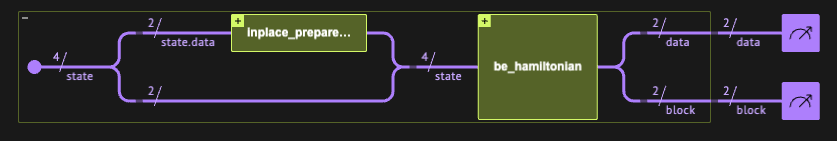

In [10]:
with ExecutionSession(qprog_be, execution_preferences=execution_preferences) as es:
    res_be = es.sample()

state_result_be = get_projected_state_vector(res_be)
expected_state_be = matrix @ state_to_evolve

renormalized_be, overlap_be = compare_quantum_classical_states(
    expected_state_be, state_result_be, BE_SCALING
)
print("Expected state:", expected_state_be)
print("Resulting state after rescaling:", renormalized_be)
assert np.linalg.norm(renormalized_be - expected_state_be) < EPS
print("=" * 40)
print("Overlap between expected and resulting state:", overlap_be)

Expected state: [0.46448797+0.j 0.2000982 +0.j 0.04532472+0.j 0.23412699+0.j]
Resulting state after rescaling: [0.46448797+2.83235782e-17j 0.2000982 -1.10893591e-16j
 0.04532472-5.34465303e-17j 0.23412699-1.38589762e-16j]
Overlap between expected and resulting state: 1.0


## Implementation

We build an LCU of the unitaries $\{W^k\}$ with coefficients $\{\beta_k\}$. The `select` operator over a series of unitary powers is implemented efficiently: instead of applying $2^l$ multi-controlled operations, we apply $l$ single-controlled operations, where the $i$-th control qubit applies $W^{2^i}$ (analogous to the QPE circuit structure).

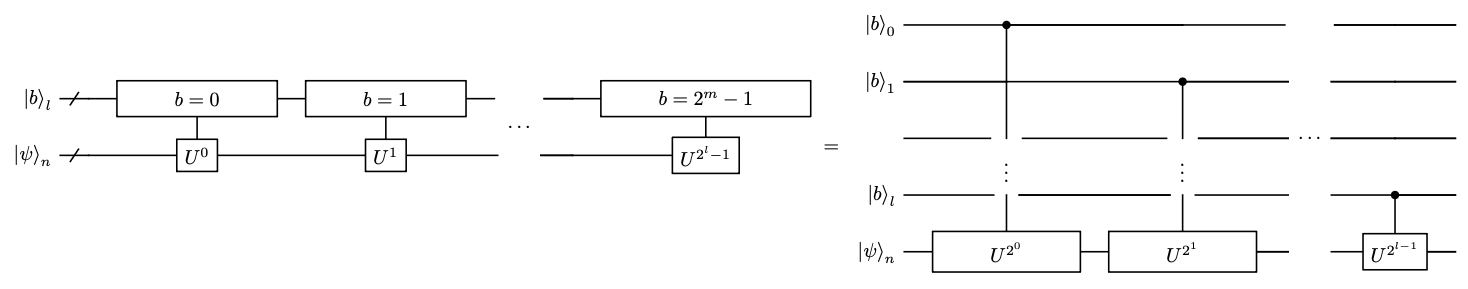
<center>
    Design of a select operation over a series of unitary powers. Instead of applying a series of $2^l$ multi-controlled operations, we can apply $l$ single controlled operations.
</center>

In [11]:
@qfunc
def select_powered_unitaries(u: QCallable, block: QArray):
    repeat(block.len, lambda i: control(block[i], lambda: power(2**i, lambda: u())))

We define Quantum Structs for the Qubitization block-encoding and assemble the `lcu_cheb` function using `prepare_select` with the efficient `select_powered_unitaries` as the select operation.

In [12]:
class QubitizationBlock(QStruct):
    block_ham: QNum[block_size]
    block_exp: QArray[exp_block_size]


class QubitizationState(QStruct):
    data: QNum[data_size]
    block: QubitizationBlock


@qfunc
def lcu_cheb(
    coefs: list[float], be_qfunc: QCallable[BlockEncodedState], state: QubitizationState
):
    prepare_select(
        coefficients=coefs,
        select=lambda lcu_block: select_powered_unitaries(
            lambda: walk_operator(be_qfunc, [state.data, state.block.block_ham]),
            lcu_block,
        ),
        block=state.block.block_exp,
    )

The code in the rest of this section builds a model that applies the `lcu_cheb` function on the randomly prepared vector, synthesizes it, executes the resulting quantum program, and verifies the results.

In [13]:
@qfunc
def main(
    data: Output[QNum[data_size]], block: Output[QNum[block_size + exp_block_size]]
):
    state = QubitizationState()
    allocate(state)
    inplace_prepare_amplitudes(state_to_evolve, 0.0, state.data)

    lcu_cheb(exp_coeffs, be_hamiltonian, state)
    bind(state, [data, block])


qprog_cheb_lcu = synthesize(main, preferences=Preferences(optimization_level=1))
show(qprog_cheb_lcu)

Quantum program link: https://platform.classiq.io/circuit/3CyiduTuSr5vBT0yL4q6JW2VGN6


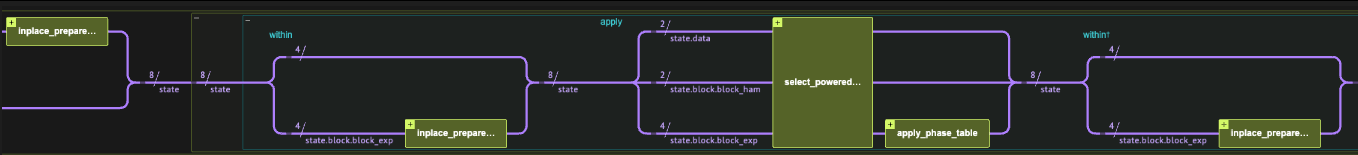

In [14]:
with ExecutionSession(qprog_cheb_lcu, execution_preferences) as es:
    results_cheb_lcu = es.sample()

state_result_cheb_lcu = get_projected_state_vector(results_cheb_lcu)
exp_scaling_factor_cheb_lcu = exp_be_scaling

In [15]:
renormalized_state_cheb_lcu, overlap_cheb_lcu = compare_quantum_classical_states(
    expected_state, state_result_cheb_lcu, exp_scaling_factor_cheb_lcu
)
print("Expected state:", expected_state)
print("Resulting state after rescaling:", renormalized_state_cheb_lcu)
assert np.linalg.norm(renormalized_state_cheb_lcu - expected_state) < EPS
print("=" * 40)
print("Overlap between expected and resulting state:", overlap_cheb_lcu)

Expected state: [-0.67645271-0.08855212j  0.53512636-0.35357791j  0.13415631-0.06325235j
 -0.22406568+0.22580629j]
Resulting state after rescaling: [-0.67645271-0.08855212j  0.53512637-0.35357791j  0.13415631-0.06325235j
 -0.22406568+0.22580629j]
Overlap between expected and resulting state: 1.0000000000000002


## References

<a id='ref-bck'>[1]</a>: [Berry, D. W., Childs, A. M., & Kothari, R. *Hamiltonian simulation with nearly optimal dependence on all parameters.* In *Proceedings of the 56th IEEE Symposium on Foundations of Computer Science (FOCS)*, pp. 792–809 (2015).](https://doi.org/10.1109/FOCS.2015.54)

<a id='ref-szegedy'>[2]</a>: [Szegedy, M. *Quantum speed-up of Markov chain based algorithms.* In *45th Annual IEEE Symposium on Foundations of Computer Science*, pp. 32–41 (2004).](https://ieeexplore.ieee.org/abstract/document/1366222)

<a id='ref-lin'>[3]</a>: [Lin, L. *Lecture notes on quantum algorithms for scientific computation.* arXiv:2201.08309 [quant-ph] (2022).](https://arxiv.org/abs/2201.08309)

## Technical Notes

### Generalizing to Non-Hermitian Block-Encoding Unitaries

The current implementation assumes that the block-encoding unitary $U_H$ is also Hermitian. This assumption underlies the walk operator's spectral properties. For a non-Hermitian block-encoding unitary, an analogous walk operator can be defined as $\tilde{W} \equiv U_H^T \Pi_{|0\rangle_m} U_H \Pi_{|0\rangle_m}$, which satisfies equivalent spectral properties. See Section 7.4 in Ref. [<a href="#ref-lin">3</a>] for details.

### Comparison with Other Methods

| Method | extra block qubits | Controlled $U_H$? | Amplitude amplification? | Classical preprocessing |
|---|---|---|---|---|
| [GQSP](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb) | 1 | Yes | No | Angle computation |
| [QSVT](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb) | 2 | No | Yes (for a factor of 2) | Angle computation |
| [Qubitization](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb) | $O(\log d)$ | Yes | Yes (for the sum of Cheb. coefficients) | None |

All three methods share the same asymptotic query complexity. Differences in the table reflect the detailed implementation of this specific example.